In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (14, 12),
    'figure.dpi': 150
})

# =====================================================================
# CONSTANTS & APPROXIMATIONS
# =====================================================================
# Based on the custom tokenizer eval for the 'fwe-val' dataset:
# Bytes: 3,024,593 | Tokens: 644,939 | Ratio = 4.69
VAL_BYTES_PER_TOKEN = 4.69 

# Mathematical conversion functions
def bpb_to_approx_loss(bpb):
    """Converts Bits-Per-Byte to approximate Cross-Entropy Loss per token."""
    return bpb * np.log(2) * VAL_BYTES_PER_TOKEN

def bpb_to_approx_ppl(bpb):
    """Converts Bits-Per-Byte to approximate Perplexity per token."""
    return np.exp(bpb_to_approx_loss(bpb))

In [12]:
import os
import glob
import re
import json
import pandas as pd
import numpy as np

# Ensure this is defined for the Approximate Perplexity calculation
VAL_BYTES_PER_TOKEN = 4.69
def bpb_to_approx_ppl(bpb):
    return 2 ** (bpb * VAL_BYTES_PER_TOKEN)

def parse_logs(log_dir="/Users/michelstahli/Optimizer_Analysis/4x_Experiment_1/logs/"):
    train_data = []
    val_data = []
    configs = {}
    memory_stats = {}
    
    log_files = glob.glob(os.path.join(log_dir, "*.out"))
    
    if not log_files:
        print(f"Warning: No .out files found in {log_dir}")
        print("Check if the path is correct or if the files have a different extension.")
        return pd.DataFrame(), pd.DataFrame(), {}, {}
    
    for file in log_files:
        with open(file, 'r') as f:
            content = f.read()
            
        # 1. Identify Optimizer
        opt_match = re.search(r"Running Optimizer:\s*([a-zA-Z0-9-]+)", content)
        if not opt_match:
            continue
        opt_name = opt_match.group(1).upper()
        
        # 2. Extract Total Batch Size
        batch_match = re.search(r"Total batch size ([\d,]+)", content)
        total_batch_size = int(batch_match.group(1).replace(',', '')) if batch_match else 131072
        
        # 3. Extract Hyperparameters Matrix
        config_match = re.search(r"Model config:\n(\{.*?\})", content, re.DOTALL)
        if config_match:
            try:
                configs[opt_name] = json.loads(config_match.group(1))
            except:
                pass

        # 4. Extract Peak Memory (if run completed/printed it before timeout)
        fwdbwd_mem = re.search(r"fwdbwd_peak_mb:\s+([0-9.]+)", content)
        optim_mem = re.search(r"optim_peak_mb:\s+([0-9.]+)", content)
        memory_stats[opt_name] = {
            "fwdbwd_peak_mb": float(fwdbwd_mem.group(1)) if fwdbwd_mem else None,
            "optim_peak_mb": float(optim_mem.group(1)) if optim_mem else None
        }

        # 5. Parse Training Steps (now including gnorm, lrm, and mfu)
        train_pattern = r"step\s+(\d+)/\d+.*?loss:\s+([0-9.]+)(?:.*?gnorm:\s+([0-9.]+))?.*?lrm:\s+([0-9.]+).*?dt:\s+([0-9.]+)ms.*?tok/sec:\s+([0-9,]+).*?bf16_mfu:\s+([0-9.]+).*?total time:\s+([0-9.]+)m"
        for m in re.finditer(train_pattern, content):
            step = int(m.group(1))
            
            train_data.append({
                "Optimizer": opt_name,
                "Step": step,
                "Tokens_Processed_Billions": (step * total_batch_size) / 1e9,
                "Train_Loss": float(m.group(2)),
                "Grad_Norm": float(m.group(3)) if m.group(3) else np.nan,
                "LR_Multiplier": float(m.group(4)),
                "Total_Step_Time_ms": float(m.group(5)),
                "Tokens_per_Second": float(m.group(6).replace(',', '')),
                "MFU": float(m.group(7)),
                "Total_Wallclock_Hours": float(m.group(8)) / 60.0
            })
            
        # 6. Parse Validation Steps
        val_matches = re.finditer(r"Step\s+(\d+)\s+\|\s+Validation bpb:\s+([0-9.]+)", content)
        for m in val_matches:
            step = int(m.group(1))
            val_bpb = float(m.group(2))
            
            val_data.append({
                "Optimizer": opt_name,
                "Step": step,
                "Tokens_Processed_Billions": (step * total_batch_size) / 1e9,
                "Val_BPB": val_bpb,
                "Approx_Val_Perplexity": bpb_to_approx_ppl(val_bpb)
            })

    df_train = pd.DataFrame(train_data)
    df_val = pd.DataFrame(val_data)
    
    return df_train, df_val, configs, memory_stats

# Execute parsing 
log_path = "/Users/michelstahli/Optimizer_Analysis/4x_Experiment_1/logs/"
df_train, df_val, configs, memory_stats = parse_logs(log_path)
print(f"Parsed {len(df_train)} training steps and {len(df_val)} validation steps.")

Parsed 4501 training steps and 8 validation steps.


In [14]:
import os
import glob
import re
import json
import pandas as pd
import numpy as np

# Updated for the 4.69 ratio from the Wendian tokenizer evaluation
VAL_BYTES_PER_TOKEN = 4.69

def bpb_to_approx_ppl(bpb):
    return 2 ** (bpb * VAL_BYTES_PER_TOKEN)

def parse_logs(log_dir="/Users/michelstahli/Optimizer_Analysis/4x_Experiment_1/logs/"):
    train_data = []
    val_data = []
    configs = {}
    memory_stats = {}
    
    log_files = glob.glob(os.path.join(log_dir, "*.out"))
    
    if not log_files:
        print(f"Warning: No .out files found in {log_dir}")
        return pd.DataFrame(), pd.DataFrame(), {}, {}
    
    for file in log_files:
        with open(file, 'r') as f:
            content = f.read()
            
        opt_match = re.search(r"Running Optimizer:\s*([a-zA-Z0-9-]+)", content)
        if not opt_match:
            continue
        opt_name = opt_match.group(1).upper()
        
        batch_match = re.search(r"Total batch size ([\d,]+)", content)
        total_batch_size = int(batch_match.group(1).replace(',', '')) if batch_match else 131072
        
        config_match = re.search(r"Model config:\n(\{.*?\})", content, re.DOTALL)
        if config_match:
            try:
                configs[opt_name] = json.loads(config_match.group(1))
            except:
                pass

        # Capture peak memory metrics for the summary table
        fwdbwd_mem = re.search(r"fwdbwd_peak_mb:\s+([0-9.]+)", content)
        optim_mem = re.search(r"optim_peak_mb:\s+([0-9.]+)", content)
        memory_stats[opt_name] = {
            "fwdbwd_peak_mb": float(fwdbwd_mem.group(1)) if fwdbwd_mem else None,
            "optim_peak_mb": float(optim_mem.group(1)) if optim_mem else None
        }

        # Comprehensive step parser
        train_pattern = r"step\s+(\d+)/\d+.*?loss:\s+([0-9.]+)(?:.*?gnorm:\s+([0-9.]+))?.*?lrm:\s+([0-9.]+).*?dt:\s+([0-9.]+)ms.*?tok/sec:\s+([0-9,]+).*?bf16_mfu:\s+([0-9.]+).*?total time:\s+([0-9.]+)m"
        for m in re.finditer(train_pattern, content):
            step = int(m.group(1))
            train_data.append({
                "Optimizer": opt_name,
                "Step": step,
                "Tokens_Processed_Billions": (step * total_batch_size) / 1e9,
                "Train_Loss": float(m.group(2)),
                "Grad_Norm": float(m.group(3)) if m.group(3) else np.nan,
                "LR_Multiplier": float(m.group(4)),
                "Total_Step_Time_ms": float(m.group(5)),
                "Tokens_per_Second": float(m.group(6).replace(',', '')),
                "MFU": float(m.group(7)),
                "Total_Wallclock_Hours": float(m.group(8)) / 60.0
            })
            
        val_matches = re.finditer(r"Step\s+(\d+)\s+\|\s+Validation bpb:\s+([0-9.]+)", content)
        for m in val_matches:
            step = int(m.group(1))
            val_bpb = float(m.group(2))
            val_data.append({
                "Optimizer": opt_name,
                "Step": step,
                "Tokens_Processed_Billions": (step * total_batch_size) / 1e9,
                "Val_BPB": val_bpb,
                "Approx_Val_Perplexity": bpb_to_approx_ppl(val_bpb)
            })

    df_train = pd.DataFrame(train_data)
    df_val = pd.DataFrame(val_data)
    return df_train, df_val, configs, memory_stats

log_path = "/Users/michelstahli/Optimizer_Analysis/4x_Experiment_1/logs/"
df_train, df_val, configs, memory_stats = parse_logs(log_path)

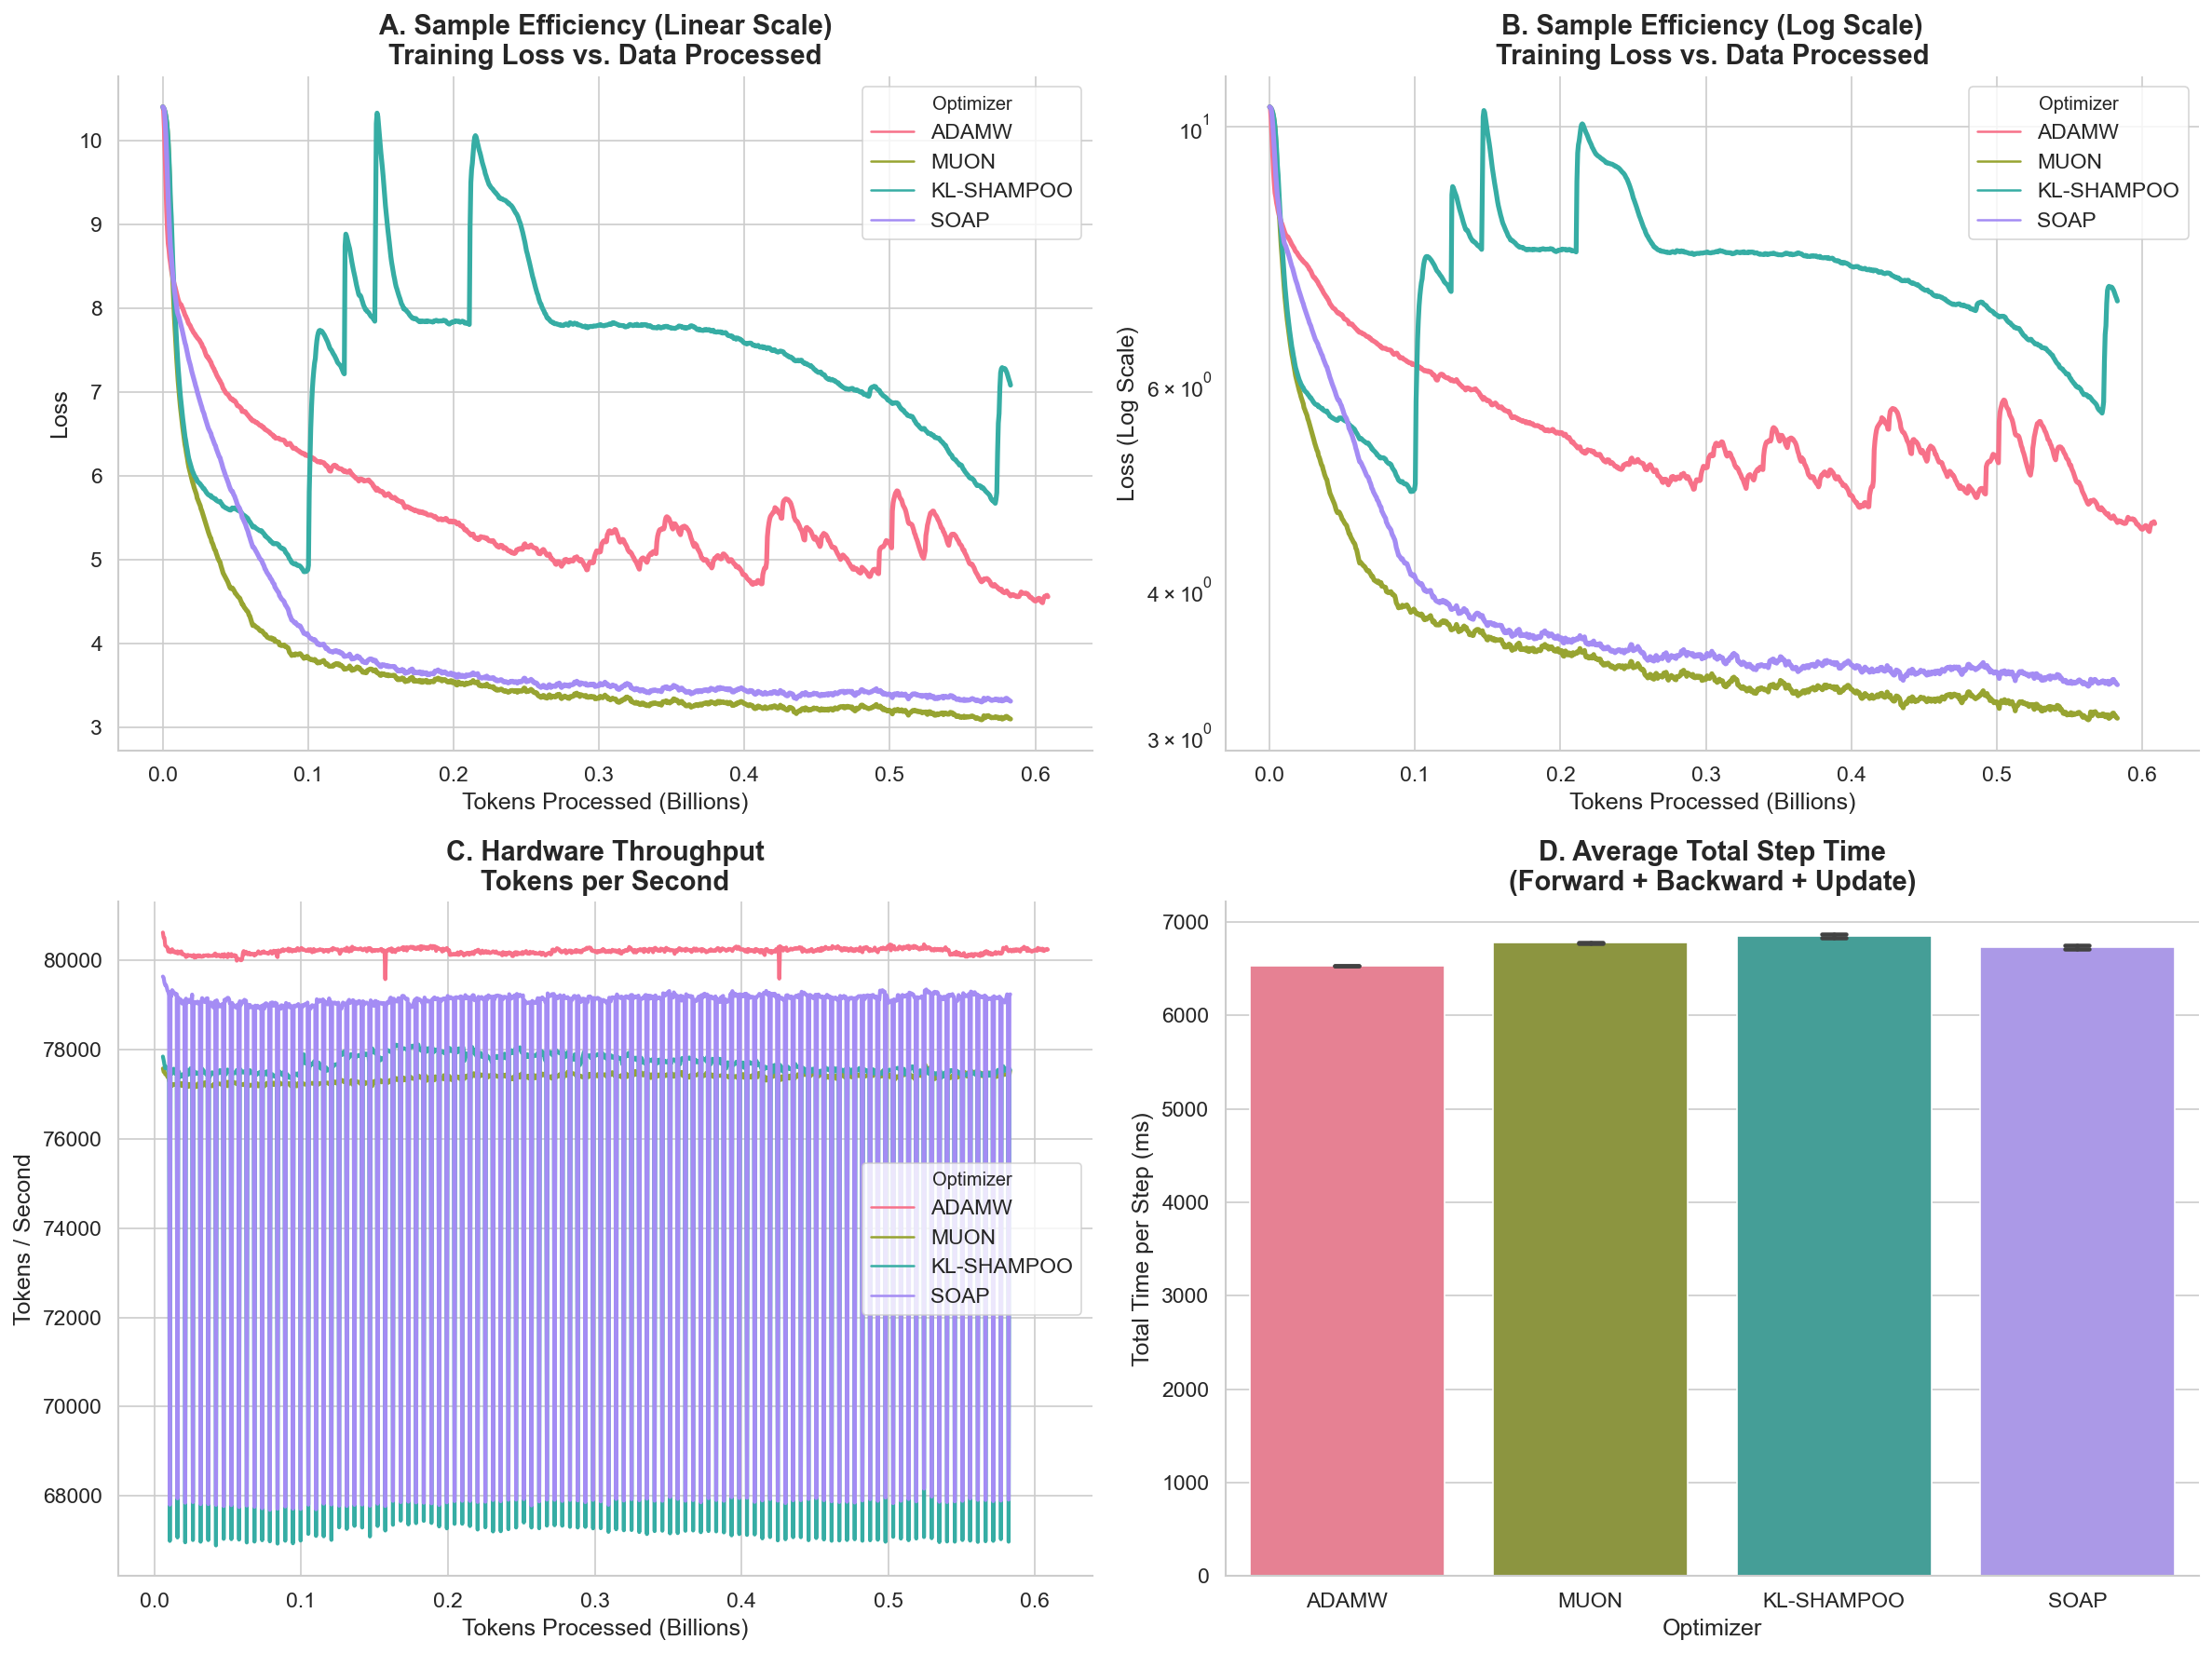


COMPREHENSIVE TRAINING METRICS (Including Memory & Stability)


,Optimizer,Final Loss,Peak MFU (%),Avg Tokens/Sec,Avg Grad Norm,Optim Memory (MB)
0,ADAMW,4.5596,0.0%,80155,N/A,None
1,MUON,3.1020,0.0%,77312,N/A,None
2,KL-SHAMPOO,7.0820,0.0%,76552,N/A,None
3,SOAP,3.3147,0.0%,77962,N/A,None



VALIDATION SUMMARY (First & Last Logged Steps)


,Optimizer,Initial BPB,Initial PPL,Last Logged BPB,Last Logged PPL
0,ADAMW,3.1733,30213.26,1.6921,244.89
1,MUON,3.1733,30213.26,0.9898,24.97
2,KL-SHAMPOO,3.1733,30213.26,1.9796,623.61
3,SOAP,3.1733,30213.26,1.0452,29.90


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Dashboard Visualization (2x2 Grid)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = sns.color_palette("husl", len(df_train['Optimizer'].unique()))

# Plot A: Training Loss vs Tokens (Linear)
sns.lineplot(data=df_train, x="Tokens_Processed_Billions", y="Train_Loss", 
             hue="Optimizer", ax=axes[0, 0], errorbar=None, linewidth=2.5, palette=palette)
axes[0, 0].set_title("A. Sample Efficiency (Linear Scale)\nTraining Loss vs. Data Processed", fontweight='bold')
axes[0, 0].set_xlabel("Tokens Processed (Billions)")
axes[0, 0].set_ylabel("Loss")

# Plot B: Training Loss vs Tokens (Log Scale) - REPLACEMENT
sns.lineplot(data=df_train, x="Tokens_Processed_Billions", y="Train_Loss", 
             hue="Optimizer", ax=axes[0, 1], errorbar=None, linewidth=2.5, palette=palette)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title("B. Sample Efficiency (Log Scale)\nTraining Loss vs. Data Processed", fontweight='bold')
axes[0, 1].set_xlabel("Tokens Processed (Billions)")
axes[0, 1].set_ylabel("Loss (Log Scale)")

# Plot C: Hardware Throughput (Formerly Plot D)
sns.lineplot(data=df_train[df_train['Step'] > 10], x="Tokens_Processed_Billions", y="Tokens_per_Second", 
             hue="Optimizer", ax=axes[1, 0], errorbar=None, linewidth=2, palette=palette)
axes[1, 0].set_title("C. Hardware Throughput\nTokens per Second", fontweight='bold')
axes[1, 0].set_xlabel("Tokens Processed (Billions)")
axes[1, 0].set_ylabel("Tokens / Second")

# Plot D: Average Total Step Time (Formerly Plot E)
sns.barplot(data=df_train[df_train['Step'] > 10], x="Optimizer", y="Total_Step_Time_ms", 
            ax=axes[1, 1], palette=palette, capsize=0.1)
axes[1, 1].set_title("D. Average Total Step Time\n(Forward + Backward + Update)", fontweight='bold')
axes[1, 1].set_xlabel("Optimizer")
axes[1, 1].set_ylabel("Total Time per Step (ms)")

sns.despine()
plt.tight_layout()
plt.savefig("optimizer_performance_2x2.pdf", bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. Comprehensive Metrics Summary Table
# ---------------------------------------------------------
train_summary = []
for opt in df_train['Optimizer'].unique():
    subset = df_train[df_train['Optimizer'] == opt]
    opt_mem = memory_stats.get(opt, {})
    
    train_summary.append({
        "Optimizer": opt,
        "Final Loss": round(subset['Train_Loss'].iloc[-1], 4),
        "Peak MFU (%)": f"{round(subset['MFU'].max() * 100, 2)}%" if not subset['MFU'].isna().all() else "N/A",
        "Avg Tokens/Sec": int(subset['Tokens_per_Second'].mean()),
        "Avg Grad Norm": round(subset['Grad_Norm'].mean(), 4) if not subset['Grad_Norm'].isna().all() else "N/A",
        "Optim Memory (MB)": opt_mem.get("optim_peak_mb", "N/A")
    })

print("\n" + "="*90)
print("COMPREHENSIVE TRAINING METRICS (Including Memory & Stability)")
print("="*90)
display(pd.DataFrame(train_summary))

# ---------------------------------------------------------
# 3. Validation Summary Table
# ---------------------------------------------------------
val_summary = []
for opt in df_val['Optimizer'].unique():
    opt_data = df_val[df_val['Optimizer'] == opt].sort_values('Step')
    if not opt_data.empty:
        first, last = opt_data.iloc[0], opt_data.iloc[-1]
        val_summary.append({
            "Optimizer": opt,
            "Initial BPB": round(first['Val_BPB'], 4),
            "Initial PPL": round(first['Approx_Val_Perplexity'], 2),
            "Last Logged BPB": round(last['Val_BPB'], 4),
            "Last Logged PPL": round(last['Approx_Val_Perplexity'], 2)
        })

print("\n" + "="*90)
print("VALIDATION SUMMARY (First & Last Logged Steps)")
print("="*90)
display(pd.DataFrame(val_summary))